# 01 · EDA — Customer Support Tickets
Real dataset: 200 tickets across 4 categories, with ground-truth `sentiment` and `risk_level` labels (not inferred).

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import matplotlib.pyplot as plt
from data_loader import load_tickets
from eda_utils import basic_profile, plot_category_counts, text_length_stats
pd.set_option('display.max_colwidth', 120)

## 1. Load & profile

In [2]:
df = load_tickets()
basic_profile(df, 'support_tickets')

--- support_tickets ---
shape: (200, 14)

dtypes:
ticket_id                             str
date_created               datetime64[us]
customer_id                           str
channel                               str
category                              str
sub_category                          str
query_text                            str
sentiment                             str
risk_level                            str
resolution_text                       str
resolution_time_minutes             int64
resolved_by                           str
customer_satisfaction               int64
escalated                            bool
dtype: object

null counts:
ticket_id                  0
date_created               0
customer_id                0
channel                    0
category                   0
sub_category               0
query_text                 0
sentiment                  0
risk_level                 0
resolution_text            0
resolution_time_minutes    0
resolved_by    

## 2. Data quality issue found: `sub_category` is corrupted
Every value is truncated mid-word (e.g. `"I see a transaction of ₹{amt} I didn't m"`), as if the field got cut off at a fixed character length during export. It also still contains the raw `{amt}` template placeholder, meaning it was captured *before* amount substitution while `query_text` was captured after. **Do not use `sub_category` for anything** — it's not usable text, and mixing it into an NLP feature would silently hurt the model.

In [3]:
print(df['sub_category'].str.len().describe())
df['sub_category'].head(5)

count    200.000000
mean      39.175000
std        2.148828
min       31.000000
25%       40.000000
50%       40.000000
75%       40.000000
max       40.000000
Name: sub_category, dtype: float64


0    I see a transaction of ₹{amt} I didn't m
1    I see a transaction of ₹{amt} I didn't m
2    I see a transaction of ₹{amt} I didn't m
3    I see a transaction of ₹{amt} I didn't m
4    I see a transaction of ₹{amt} I didn't m
Name: sub_category, dtype: str

## 3. Category distribution
Perfectly balanced — 50 tickets per category. Good for training, but worth knowing this is a deliberately balanced synthetic set, not organic ticket volume.

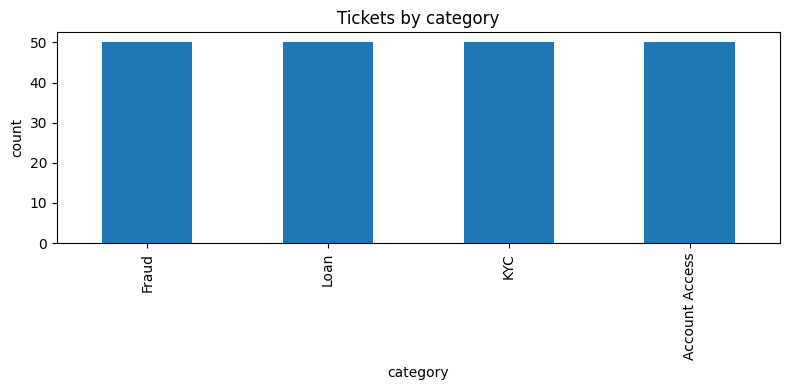

In [4]:
cat_counts = plot_category_counts(df, 'category', title='Tickets by category')

## 4. Query text is templated — only 66 unique phrasings across 200 rows
The same handful of query templates repeat ~3x each (with the ₹ amount and date swapped). This matters for modeling: a classifier trained on this data is really learning to recognize ~66 templates, not learning to generalize to novel customer phrasing. Treat any downstream accuracy score as a pipeline sanity-check, not a production estimate.

In [5]:
print('Unique query_text:', df['query_text'].nunique(), '/', len(df))
df['query_text'].value_counts().head(10)

Unique query_text: 66 / 200


query_text
I received an OTP but never requested it                           5
Multiple small transactions from my account I don't recognize      5
Someone used my credit card online without my knowledge            5
My UPI ID was used to transfer money without my consent            5
My personal loan was approved but I haven't received the amount    5
Why was my loan application rejected?                              5
I applied for a business loan 3 weeks ago and heard nothing        5
Can I get an education loan for my child?                          5
My EMI was deducted twice this month                               5
I want to foreclose my car loan                                    5
Name: count, dtype: int64

count    200.000000
mean       9.550000
std        1.646528
min        6.000000
25%        8.750000
50%       10.000000
75%       11.000000
max       12.000000
Name: query_text, dtype: float64


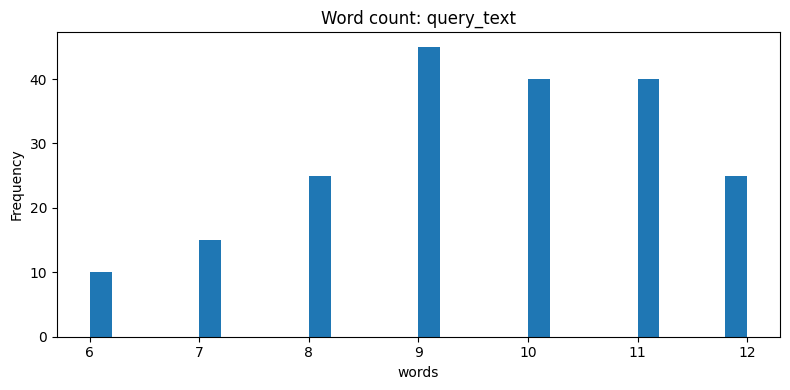

In [6]:
lengths = text_length_stats(df, 'query_text')

## 5. Sentiment distribution — and whether it's actually predictable from text
6 sentiment classes (Anxious, Confused, Urgent, Neutral, Frustrated, Angry), fairly evenly spread. **Key finding:** the same query template appears with *different* sentiment labels across duplicate rows — sentiment looks assigned independently of wording, not derived from it. A text classifier trained on `query_text -> sentiment` gets ~20% accuracy (near-random for 6 classes) in `src/intent_classifier.py` — confirming sentiment isn't recoverable from this text field in this dataset.

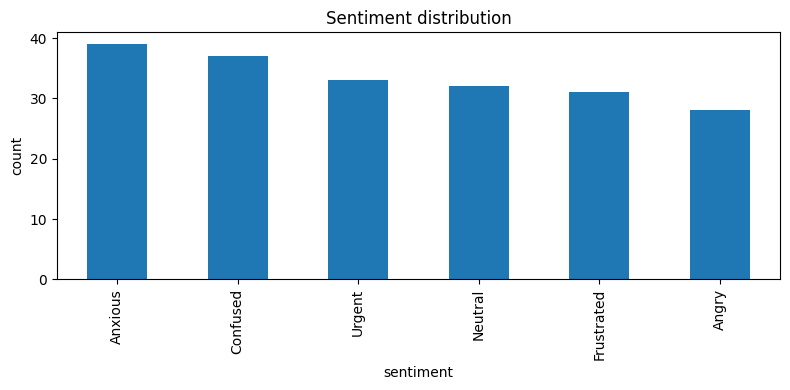

sentiment
Anxious       39
Confused      37
Urgent        33
Neutral       32
Frustrated    31
Angry         28
Name: count, dtype: int64

In [7]:
plot_category_counts(df, 'sentiment', title='Sentiment distribution')

In [8]:
dupe_sentiment = df[df.duplicated('query_text', keep=False)].sort_values('query_text')[['query_text','sentiment','risk_level']]
dupe_sentiment.head(10)

,query_text,sentiment,risk_level
70,Can I get an education loan for my child?,Neutral,Low
71,Can I get an education loan for my child?,Angry,Low
72,Can I get an education loan for my child?,Anxious,Low
73,Can I get an education loan for my child?,Frustrated,Low
74,Can I get an education loan for my child?,Urgent,Low
65,I applied for a business loan 3 weeks ago and heard nothing,Anxious,Medium
66,I applied for a business loan 3 weeks ago and heard nothing,Urgent,Medium
67,I applied for a business loan 3 weeks ago and heard nothing,Angry,Medium
68,I applied for a business loan 3 weeks ago and heard nothing,Anxious,Medium
69,I applied for a business loan 3 weeks ago and heard nothing,Angry,Medium


## 6. Risk level correlates strongly with category (not sentiment)
Fraud tickets are mostly High/Medium risk; Account Access is almost all Low; KYC splits Low/Medium; Loan splits Low/Medium with a bit of High. Sentiment, by contrast, is roughly uniform across risk levels — **category, not emotional tone, is what actually predicts risk in this dataset.**

In [9]:
pd.crosstab(df['category'], df['risk_level'])

risk_level,High,Low,Medium
category,,,
Account Access,0,45,5
Fraud,30,10,10
KYC,0,20,30
Loan,5,30,15


In [10]:
pd.crosstab(df['sentiment'], df['risk_level'])

risk_level,High,Low,Medium
sentiment,,,
Angry,6,12,10
Anxious,5,23,11
Confused,5,14,18
Frustrated,4,19,8
Neutral,9,17,6
Urgent,6,20,7


## 7. Resolution time & escalation
Escalation is rare (17/200 = 8.5%). Does resolution time or satisfaction differ by category or risk level?

In [11]:
df.groupby('category')[['resolution_time_minutes','customer_satisfaction']].mean()

,resolution_time_minutes,customer_satisfaction
category,,
Account Access,131.06,4.04
Fraud,47.10,3.74
KYC,84.96,4.12
Loan,100.00,3.82


In [12]:
df.groupby('risk_level')[['resolution_time_minutes','customer_satisfaction']].mean()

,resolution_time_minutes,customer_satisfaction
risk_level,,
High,18.542857,3.571429
Low,133.952381,4.019048
Medium,57.366667,3.983333


## 8. Channel mix

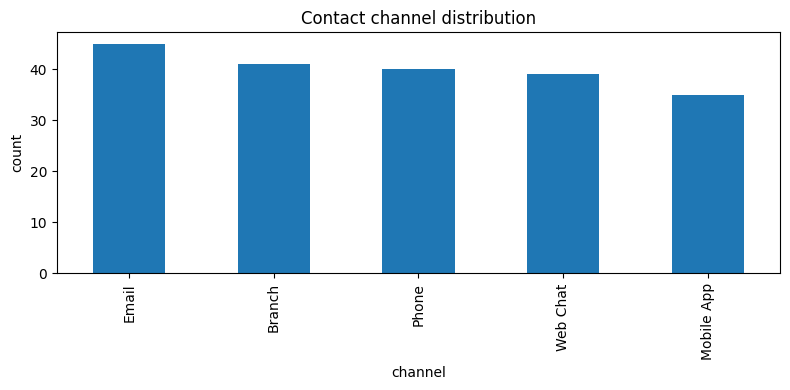

channel
Email         45
Branch        41
Phone         40
Web Chat      39
Mobile App    35
Name: count, dtype: int64

In [13]:
plot_category_counts(df, 'channel', title='Contact channel distribution')

## 9. Takeaways
- Categories are clean and balanced (50/50/50/50) — good intent-classifier training signal.
- **`sub_category` is corrupted (truncated + unsubstituted template) — excluded from modeling.**
- Query text is templated (66 unique phrasings) — held-out accuracy will look better than real-world generalization will be; recommend augmenting with paraphrasing before production.
- Sentiment is **not** predictable from query_text alone in this dataset (~20% accuracy, near-random) — either the label generation was randomized, or a real sentiment signal needs more context (tone markers, punctuation, escalation history) than the query text alone.
- Risk level is well predicted by category — a simple category-based rule would already get most of the way there; the trained text model (`src/risk_classifier.py`) confirms this.